Explanation of Metrics:
Precision:

Formula: 
Precision
=
True Positives
True Positives
+
False Positives
Precision= 
True Positives+False Positives
True Positives
​
 
Measures how many of the predicted relevant results are truly relevant.
Recall:

Formula: 
Recall
=
True Positives
True Positives
+
False Negatives
Recall= 
True Positives+False Negatives
True Positives
​
 
Measures how many of the relevant results were retrieved.
F1 Score:

Formula: 
F1 Score
=
2
⋅
Precision
⋅
Recall
Precision
+
Recall
F1 Score=2⋅ 
Precision+Recall
Precision⋅Recall
​
 
Harmonic mean of precision and recall.
Accuracy:

Formula: 
Accuracy
=
True Positives
+
True Negatives
Total Instances
Accuracy= 
Total Instances
True Positives+True Negatives
​
 
Measures the overall correctness of predictions.

In [1]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('aas_query_results.csv')#'evaluation_results.csv')

# Display the first few rows of the DataFrame
df.head()


,Query,Expected,Generated,Accuracy,BERT F1,BERT Precision,BERT Recall,BLEU,BLEURT,BLEURT Score,...,Precision,ROUGE-1,ROUGE-2,ROUGE-L,Recall,SBERT Cosine,Sentence-BERT Cosine Similarity,Token F1,Token Precision,Token Recall
0,Name all drilling machines,The drilling machines mentioned are: GreenHarm...,"Based on the provided data, the following are ...",NaN,0.472863,0.332520,0.639246,0.006142,NaN,0.069592,...,0.188679,0.567164,0.276923,0.238806,0.526316,NaN,0.926262,NaN,NaN,NaN
1,Tell me more about titancraft pro,The TitanCraft Pro-1 is a high-performance dri...,The TitanCraft Pro-1 is a heavy-duty drill des...,NaN,0.247744,0.022940,0.579586,0.103462,NaN,-0.661198,...,0.175824,0.405797,0.235294,0.304348,0.444444,NaN,0.889475,NaN,NaN,NaN
2,Name all circular saws,The circular saw mentioned is the SwiftSaw Pre...,The following circular saws were found in the ...,NaN,-0.128528,-0.273944,0.068543,0.004375,NaN,-0.791767,...,0.050847,0.203390,0.070175,0.203390,0.375000,NaN,0.720429,NaN,NaN,NaN
3,Name all circular saws (Breadth: 20),The circular saws mentioned are: SwiftSaw Prec...,The following circular saws are available:\n\n...,NaN,0.483597,0.381051,0.596971,0.009789,NaN,0.166997,...,0.218750,0.659091,0.348837,0.295455,0.482759,NaN,0.941570,NaN,NaN,NaN
4,Name available drilling machines,The available drilling machines are 20 models ...,The following drilling machines are available:...,NaN,0.086879,-0.002921,0.184500,0.007051,NaN,-0.627486,...,0.049689,0.128713,0.030000,0.108911,0.153846,NaN,0.528577,NaN,NaN,NaN


global metrics

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set(style="whitegrid")

# Create a DataFrame with global metrics (one value per query)
global_metrics = df[['query', 'global_precision', 'global_recall', 'global_f1_score', 'global_accuracy']]

# Melt the DataFrame to plot multiple metrics in a single plot
global_metrics_melted = global_metrics.melt(id_vars='query', 
                                            value_vars=['global_precision', 'global_recall', 'global_f1_score', 'global_accuracy'],
                                            var_name='Metric', value_name='Score')

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Metric', y='Score', data=global_metrics_melted, palette="Set2")
plt.title('Global Metrics Distribution for All Queries')
plt.show()


KeyError: "None of [Index(['query', 'global_precision', 'global_recall', 'global_f1_score',\n       'global_accuracy'],\n      dtype='object')] are in the [columns]"

scores for each query

C:\Users\TempUser\AppData\Local\Temp\ipykernel_5440\2793318347.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='query', y='bleu_score', data=df, palette="Blues_d")


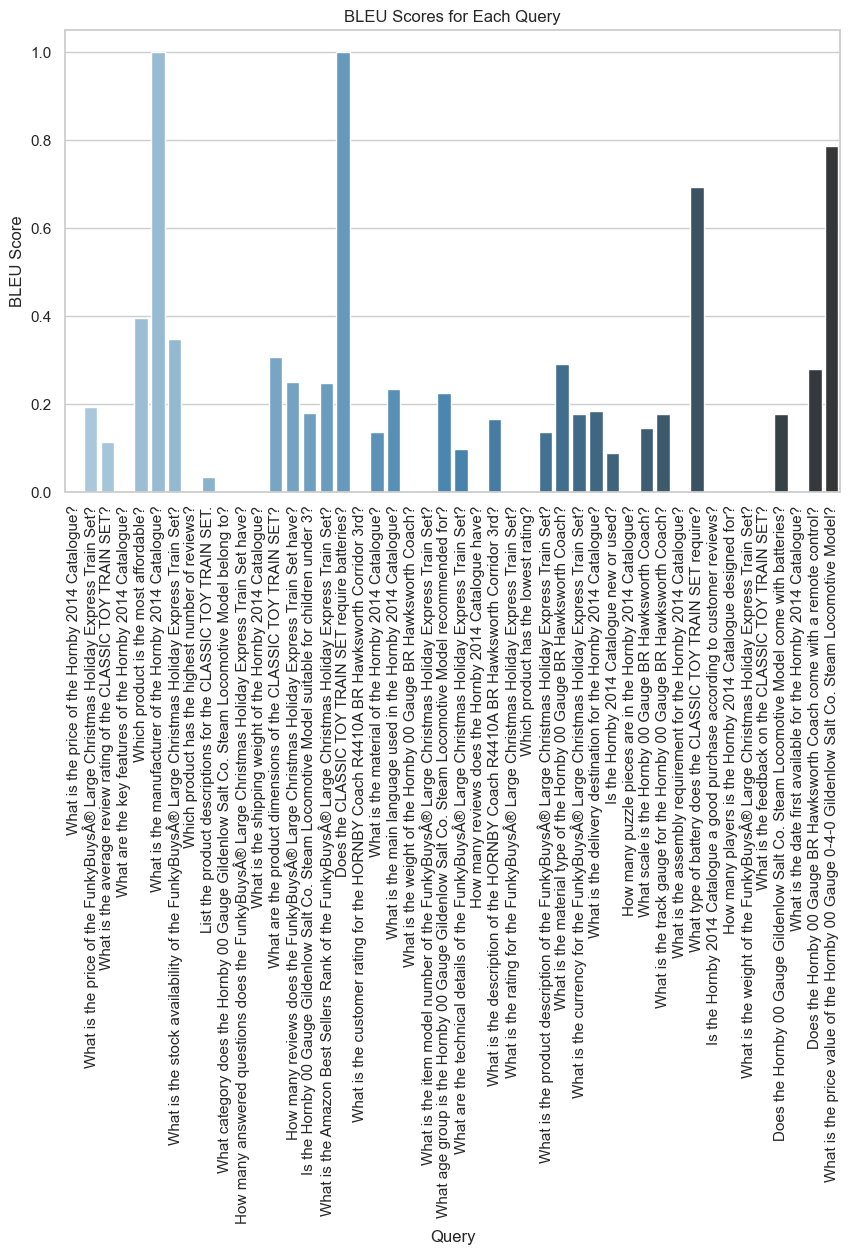

C:\Users\TempUser\AppData\Local\Temp\ipykernel_5440\2793318347.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='query', y='rouge1', data=df, palette="Reds_d")


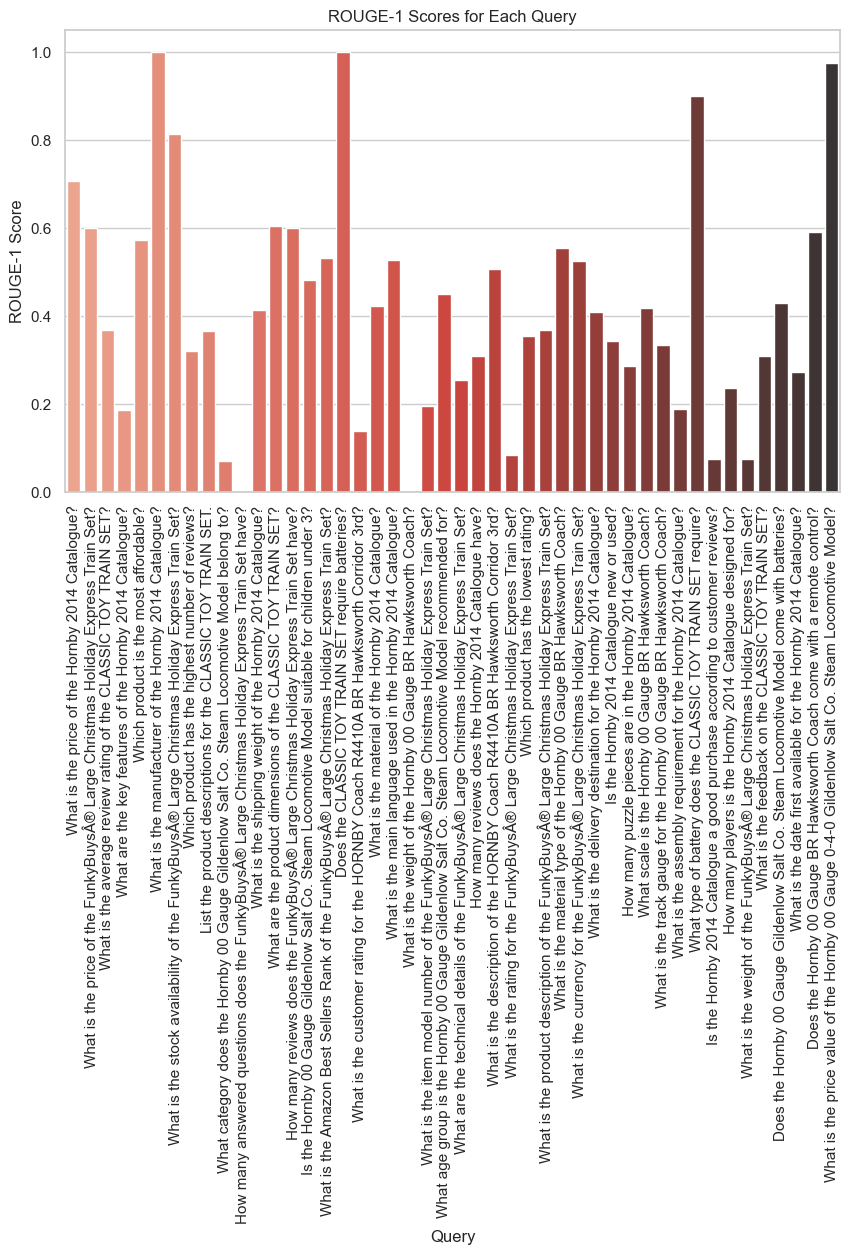

C:\Users\TempUser\AppData\Local\Temp\ipykernel_5440\2793318347.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='query', y='cosine_similarity', data=df, palette="Greens_d")


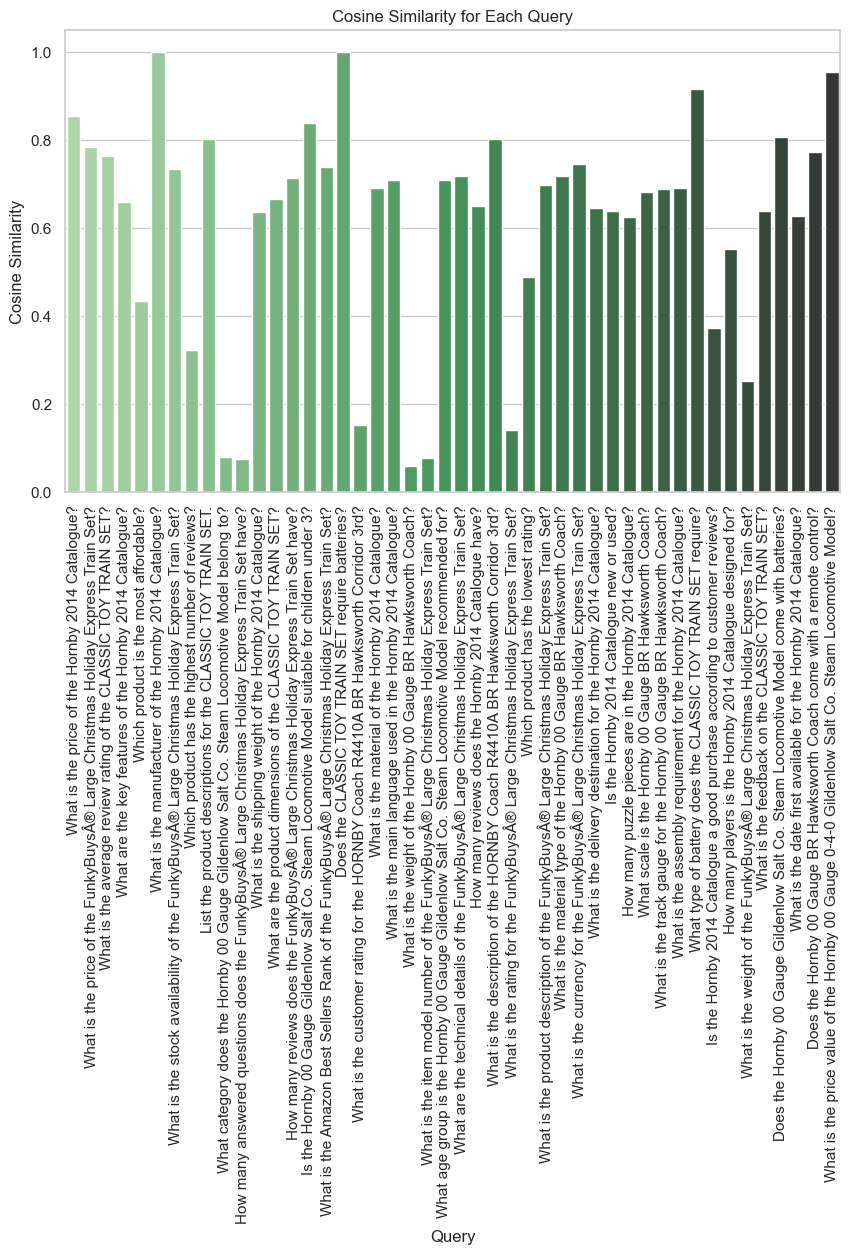

In [16]:
# Plot BLEU Score for each query
plt.figure(figsize=(10, 6))
sns.barplot(x='query', y='bleu_score', data=df, palette="Blues_d")
plt.xticks(rotation=90)
plt.title('BLEU Scores for Each Query')
plt.xlabel('Query')
plt.ylabel('BLEU Score')
plt.show()

# Plot ROUGE-1 Score for each query
plt.figure(figsize=(10, 6))
sns.barplot(x='query', y='rouge1', data=df, palette="Reds_d")
plt.xticks(rotation=90)
plt.title('ROUGE-1 Scores for Each Query')
plt.xlabel('Query')
plt.ylabel('ROUGE-1 Score')
plt.show()

# Plot Cosine Similarity for each query
plt.figure(figsize=(10, 6))
sns.barplot(x='query', y='cosine_similarity', data=df, palette="Greens_d")
plt.xticks(rotation=90)
plt.title('Cosine Similarity for Each Query')
plt.xlabel('Query')
plt.ylabel('Cosine Similarity')
plt.show()


pairwise corelation between metrics

c:\Users\TempUser\Documents\code\ijs_E3\rag-knowledge-graph\venv\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\TempUser\Documents\code\ijs_E3\rag-knowledge-graph\venv\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


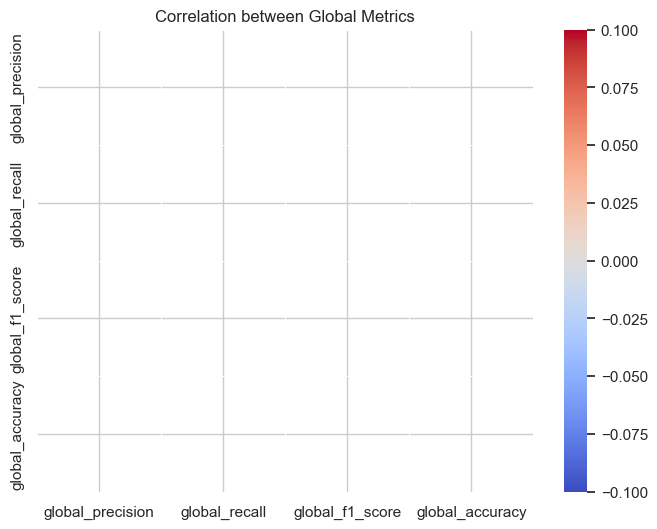

In [5]:
# Select only the relevant columns for correlation
metrics_columns = ['global_precision', 'global_recall', 'global_f1_score', 'global_accuracy']
metrics_df = df[metrics_columns]

# Calculate the correlation matrix
corr_matrix = metrics_df.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title('Correlation between Global Metrics')
plt.show()


distribution of cosine similarity

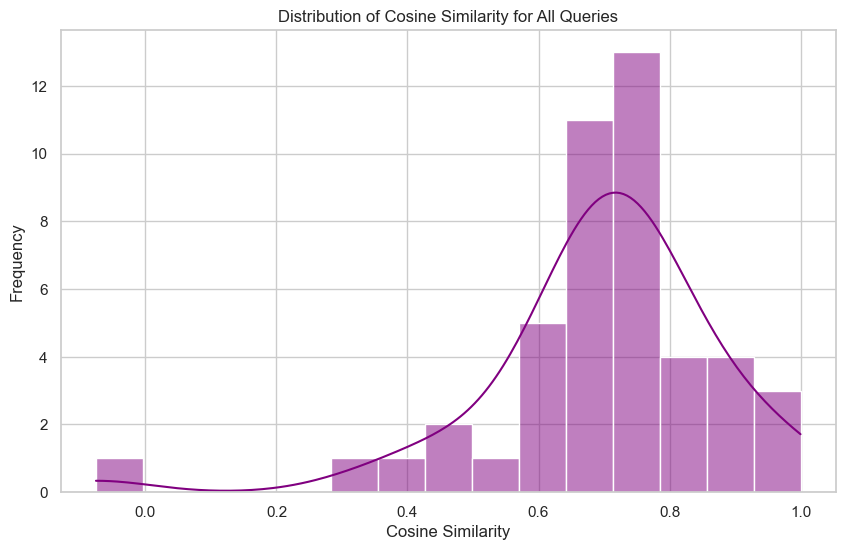

In [6]:
# Plot the distribution of cosine similarity
plt.figure(figsize=(10, 6))
sns.histplot(df['cosine_similarity'], kde=True, color='purple', bins=15)
plt.title('Distribution of Cosine Similarity for All Queries')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.show()


top 10 querys by belu score

C:\Users\TempUser\AppData\Local\Temp\ipykernel_5440\3658623865.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='query', y='bleu_score', data=top_queries_bleu, palette="Blues_d")


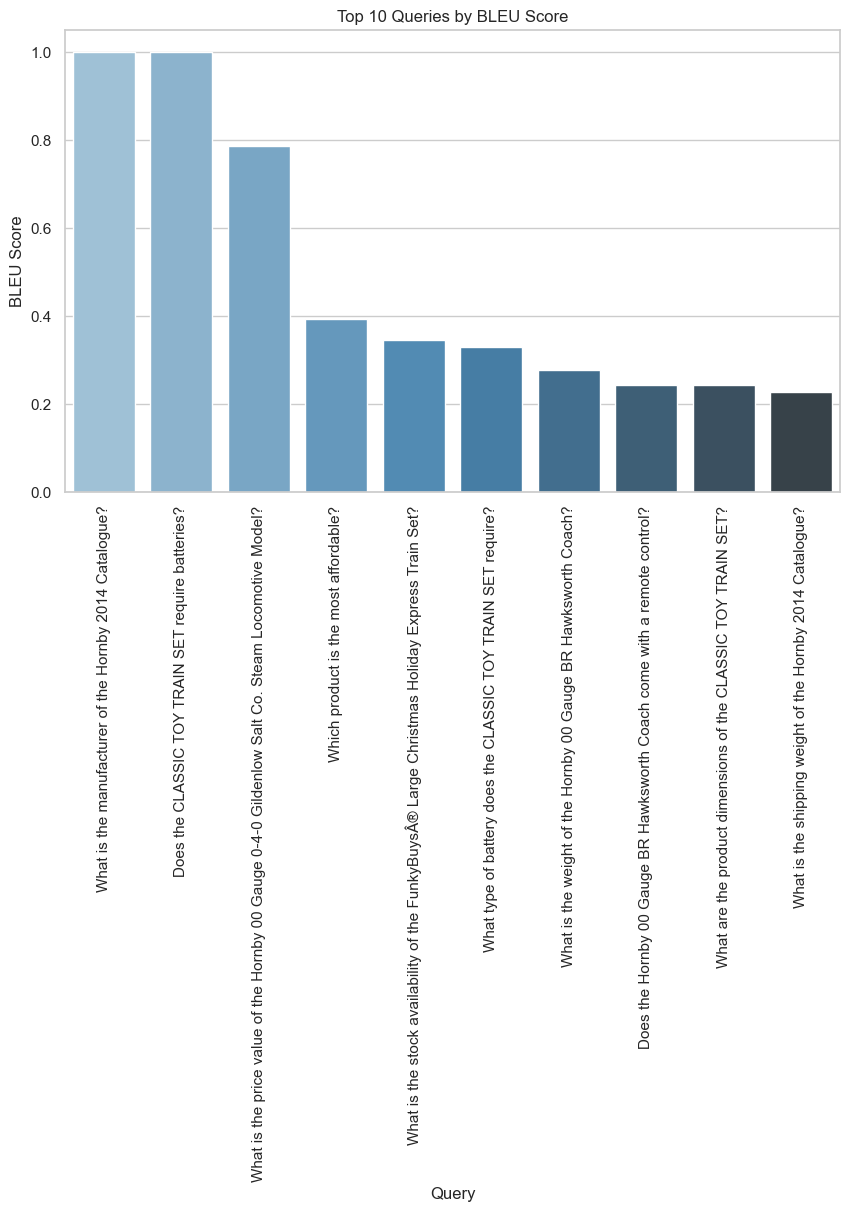

In [7]:
# Sort by BLEU Score and select top 10 queries
top_queries_bleu = df.sort_values('bleu_score', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='query', y='bleu_score', data=top_queries_bleu, palette="Blues_d")
plt.xticks(rotation=90)
plt.title('Top 10 Queries by BLEU Score')
plt.xlabel('Query')
plt.ylabel('BLEU Score')
plt.show()


**with bertscore**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV results
results_file = "query_results.csv"
data = pd.read_csv(results_file)

# Display the first few rows for verification
data.head()


,Query,Expected,Generated,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,Cosine Similarity,BERT Precision,BERT Recall,BERT F1,Precision,Recall,F1-Score
0,What is the price of the Hornby 2014 Catalogue?,The price of the Hornby 2014 Catalogue is Â£3.42.,The Hornby 2014 Catalogue costs £3.42.,3.764142e-78,0.705882,0.533333,0.705882,0.608773,0.867237,0.751173,0.808196,0.666667,0.444444,0.533333
1,What is the price of the FunkyBuysÂ® Large Chr...,The price of the FunkyBuysÂ® Large Christmas H...,"I am sorry, I cannot answer your question. The...",1.808713e-01,0.550000,0.526316,0.550000,0.427163,0.317426,0.466639,0.390667,0.307692,0.615385,0.410256
2,What is the average review rating of the CLASS...,The average review rating of the CLASSIC TOY T...,"The provided results show only one item, the C...",6.898106e-02,0.250000,0.139535,0.227273,0.658020,-0.093253,0.409141,0.110081,0.154930,0.916667,0.265060
3,What are the key features of the Hornby 2014 C...,The Hornby 2014 Catalogue includes detailed de...,The provided results only give the product nam...,6.473159e-79,0.131387,0.044444,0.087591,0.257157,-0.111125,0.209775,0.030187,0.051724,0.400000,0.091603
4,Which product is the most affordable?,The most affordable product is the Hornby 2014...,The most affordable product is the Happy 18th ...,3.934996e-01,0.571429,0.461538,0.571429,0.505606,0.620830,0.588589,0.606146,0.571429,0.666667,0.615385


bertscore

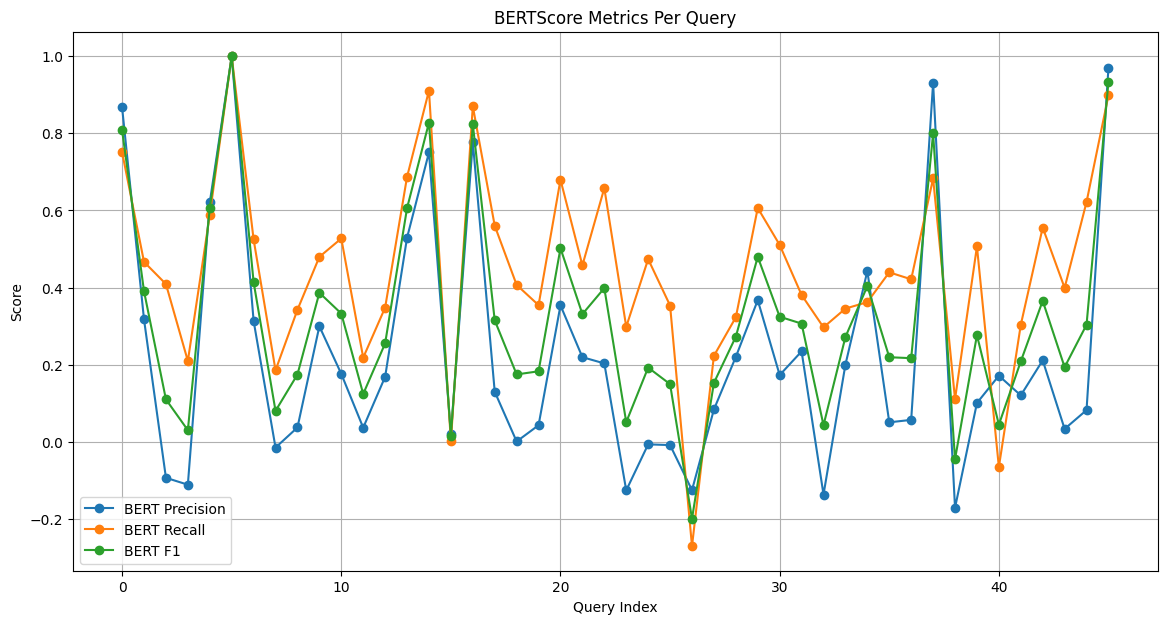

In [3]:
plt.figure(figsize=(14, 7))
plt.plot(data.index, data["BERT Precision"], label="BERT Precision", marker='o')
plt.plot(data.index, data["BERT Recall"], label="BERT Recall", marker='o')
plt.plot(data.index, data["BERT F1"], label="BERT F1", marker='o')
plt.title("BERTScore Metrics Per Query")
plt.xlabel("Query Index")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()


correlation heatmap for metrics

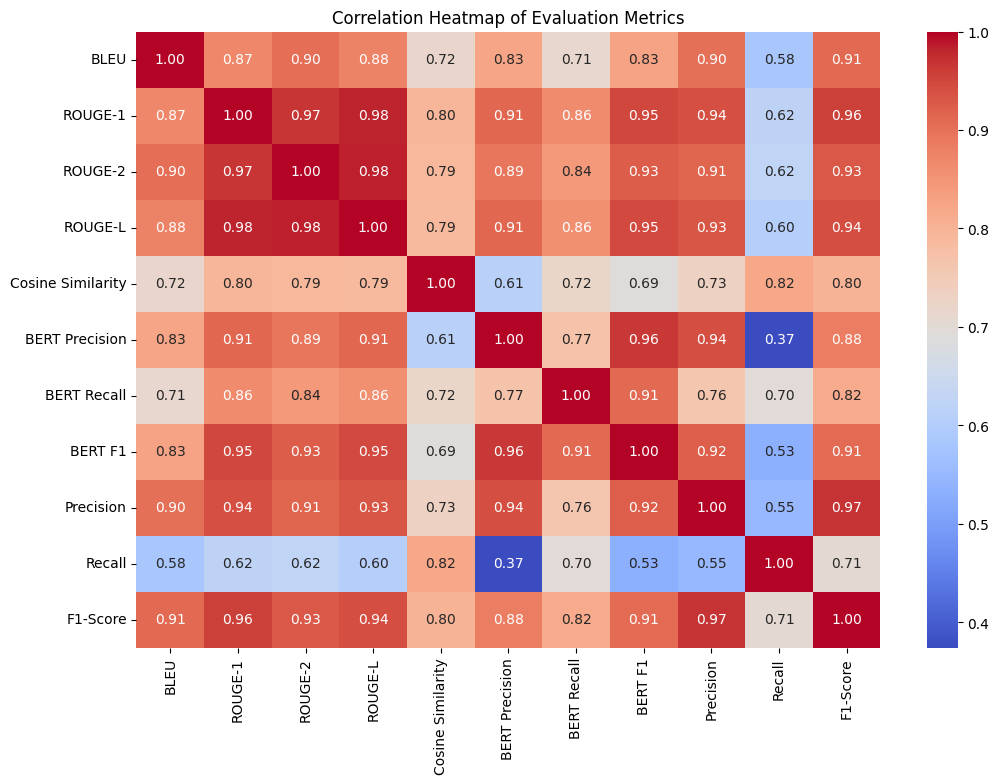

In [5]:
# Select only numeric columns for correlation
numeric_data = data.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Evaluation Metrics")
plt.show()


distribution of bert f1 score

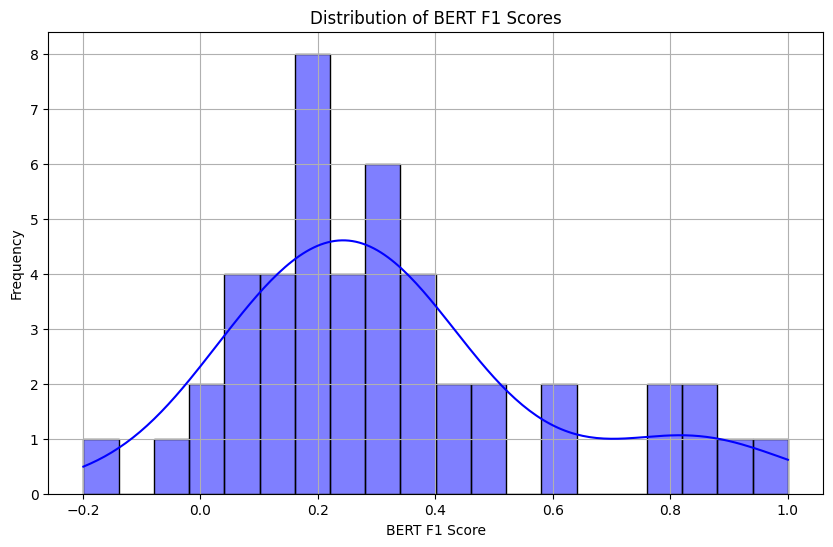

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(data["BERT F1"], kde=True, bins=20, color="blue")
plt.title("Distribution of BERT F1 Scores")
plt.xlabel("BERT F1 Score")
plt.ylabel("Frequency")
plt.grid()
plt.show()


bert f1 vs other metrics

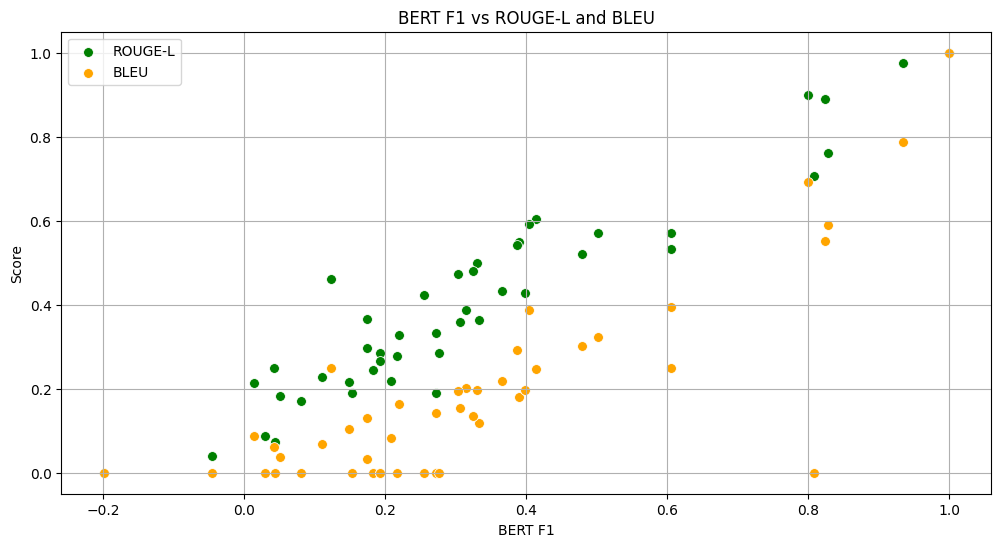

In [7]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x="BERT F1", y="ROUGE-L", data=data, label="ROUGE-L", color="green", s=50)
sns.scatterplot(x="BERT F1", y="BLEU", data=data, label="BLEU", color="orange", s=50)
plt.title("BERT F1 vs ROUGE-L and BLEU")
plt.xlabel("BERT F1")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()


per-query comparison with emphasis on bert f1

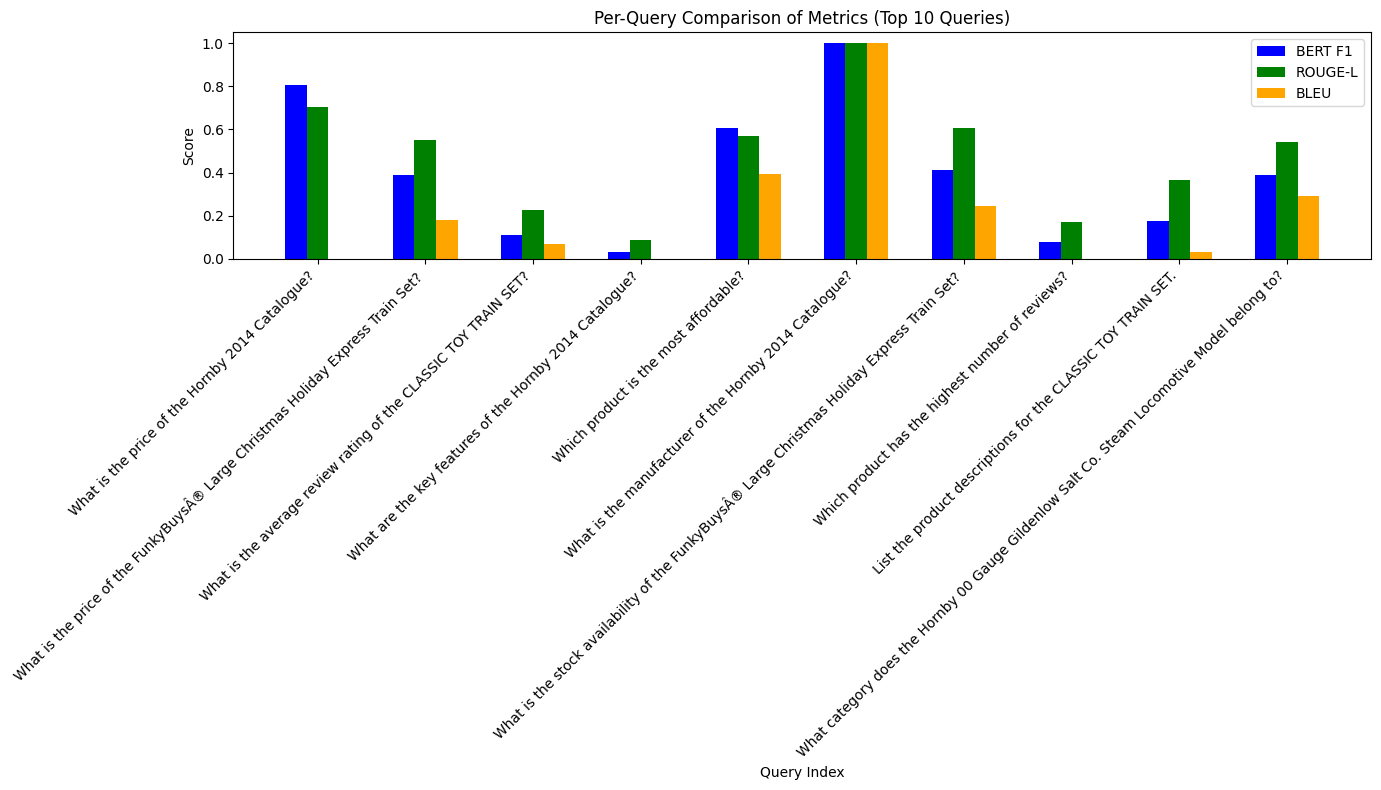

In [8]:
selected_queries = data.head(10)  # Select the first 10 queries for demonstration

plt.figure(figsize=(14, 8))
bar_width = 0.2
index = range(len(selected_queries))

plt.bar(index, selected_queries["BERT F1"], bar_width, label="BERT F1", color="blue")
plt.bar([i + bar_width for i in index], selected_queries["ROUGE-L"], bar_width, label="ROUGE-L", color="green")
plt.bar([i + 2 * bar_width for i in index], selected_queries["BLEU"], bar_width, label="BLEU", color="orange")

plt.title("Per-Query Comparison of Metrics (Top 10 Queries)")
plt.xlabel("Query Index")
plt.ylabel("Score")
plt.xticks([i + bar_width for i in index], selected_queries["Query"], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


c:\Users\ailab\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Visualizing Metrics...


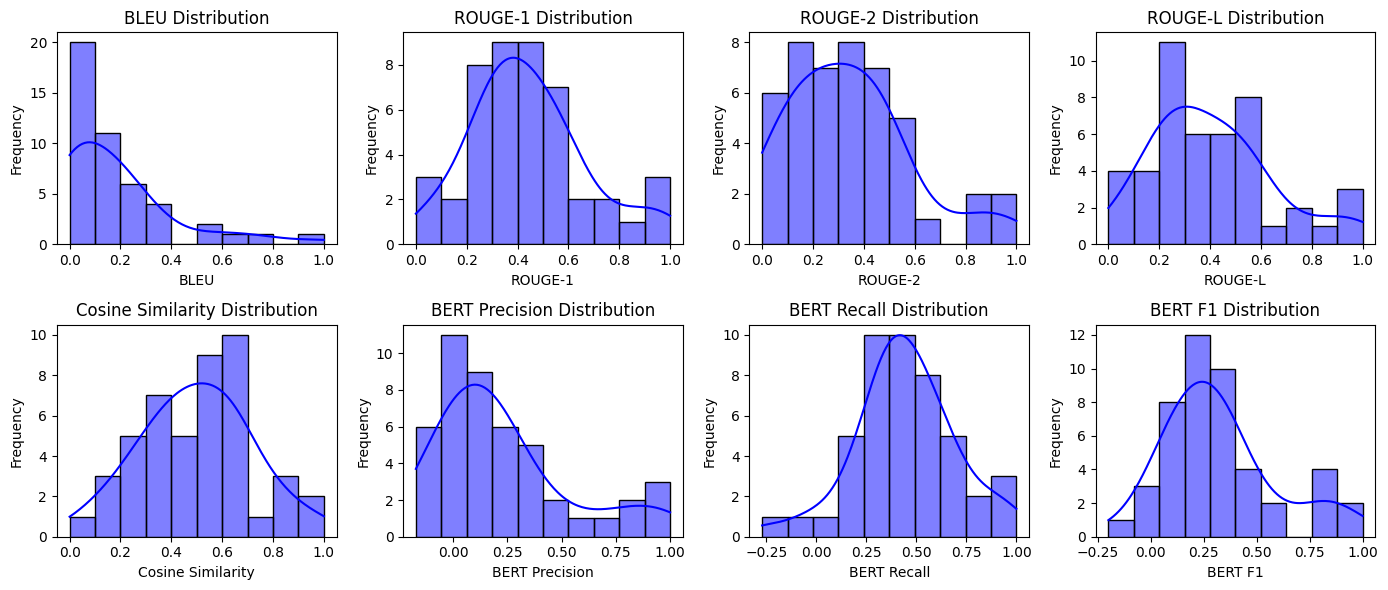

Generating BERTScore Heatmaps...


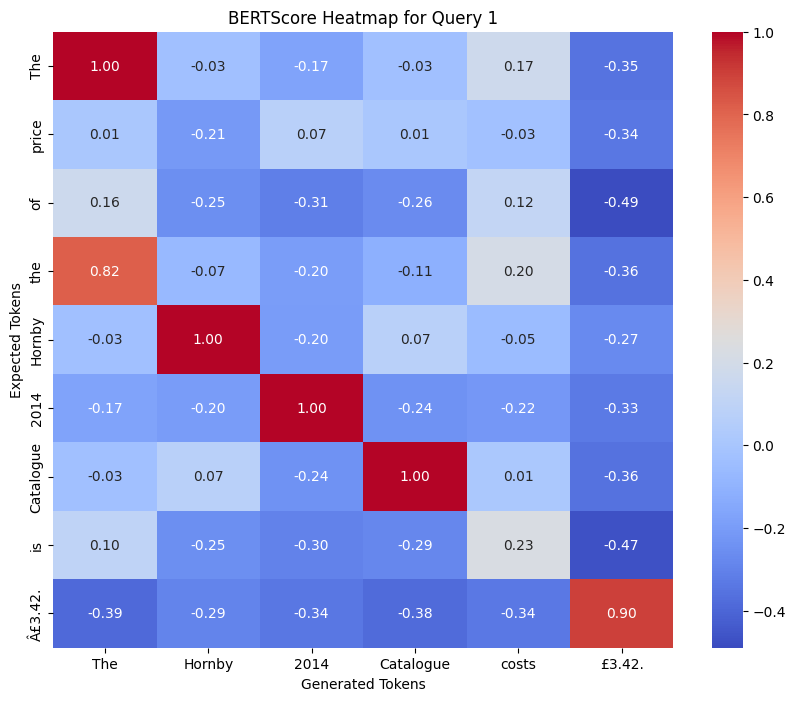

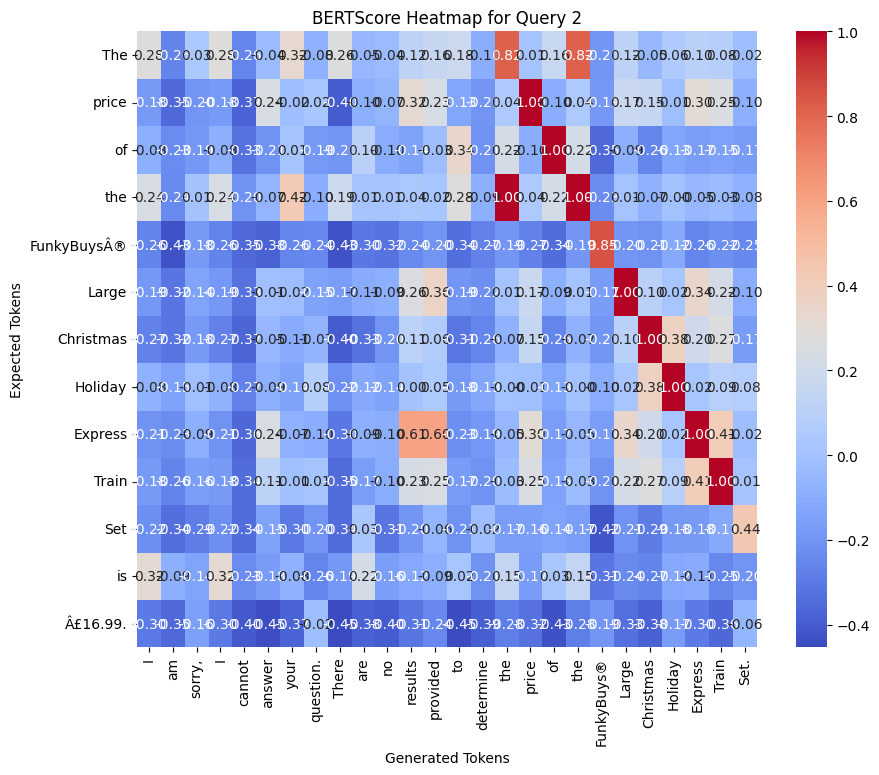

KeyboardInterrupt: 

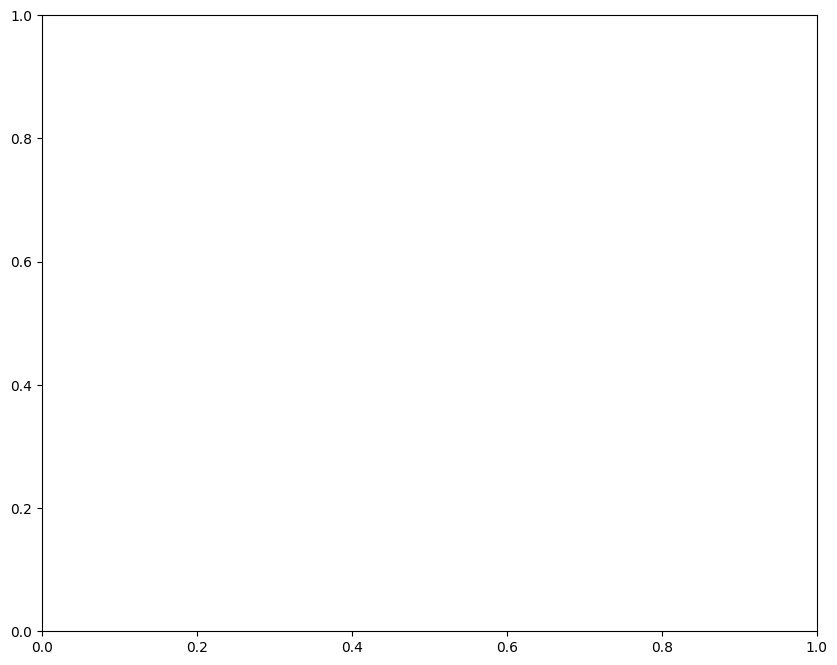

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from bert_score import BERTScorer
import numpy as np

# Load the CSV file
csv_file = "query_results.csv"
data = pd.read_csv(csv_file)

# Initialize BERTScorer for Heatmaps
bert_scorer = BERTScorer(model_type="microsoft/deberta-xlarge-mnli", lang="en", rescale_with_baseline=True)

# Function to create heatmaps for BERTScore
def plot_bert_heatmap(expected, generated, ax, title):
    # Tokenize the sentences
    expected_tokens = expected.split()
    generated_tokens = generated.split()
    
    # Calculate similarity scores between every pair of tokens
    scores = np.zeros((len(expected_tokens), len(generated_tokens)))
    for i, e_token in enumerate(expected_tokens):
        for j, g_token in enumerate(generated_tokens):
            _, _, f1 = bert_scorer.score([g_token], [e_token])
            scores[i, j] = f1.item()

    # Create heatmap
    sns.heatmap(
        scores, annot=True, fmt=".2f", xticklabels=generated_tokens, yticklabels=expected_tokens, ax=ax, cmap="coolwarm"
    )
    ax.set_title(title)
    ax.set_xlabel("Generated Tokens")
    ax.set_ylabel("Expected Tokens")

# Visualize metrics as bar plots
def plot_metrics(data):
    metrics = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "Cosine Similarity", "BERT Precision", "BERT Recall", "BERT F1"]
    plt.figure(figsize=(14, 6))
    for i, metric in enumerate(metrics, 1):
        plt.subplot(2, 4, i)
        sns.histplot(data[metric], kde=True, bins=10, color="blue")
        plt.title(f"{metric} Distribution")
        plt.xlabel(metric)
        plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Generate segments with BERTScore heatmaps
def plot_segments(data):
    for idx, row in data.iterrows():
        expected = row["Expected"]
        generated = row["Generated"]
        
        # Plot heatmap
        fig, ax = plt.subplots(figsize=(10, 8))
        plot_bert_heatmap(expected, generated, ax, f"BERTScore Heatmap for Query {idx + 1}")
        plt.show()

# Visualize metrics
print("Visualizing Metrics...")
plot_metrics(data)

# Generate BERTScore heatmaps
print("Generating BERTScore Heatmaps...")
plot_segments(data)


with bert cosine similarity

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load evaluation results
results_csv = "query_results.csv"
results_df = pd.read_csv(results_csv)

# Display the first few rows to ensure the file is loaded correctly
print(results_df.head())

# Set up the visualization style
sns.set(style="whitegrid")

                                               Query  \
0    What is the price of the Hornby 2014 Catalogue?   
1  What is the price of the FunkyBuysÂ® Large Chr...   
2  What is the average review rating of the CLASS...   
3              Which product is the most affordable?   
4  What is the manufacturer of the Hornby 2014 Ca...   

                                            Expected  \
0  The price of the Hornby 2014 Catalogue is Â£3.42.   
1  The price of the FunkyBuysÂ® Large Christmas H...   
2  The average review rating of the CLASSIC TOY T...   
3  The most affordable product is the Happy 18th ...   
4  The manufacturer of the Hornby 2014 Catalogue ...   

                                           Generated      BLEU   ROUGE-1  \
0             The Hornby 2014 Catalogue costs £3.42.  0.308198  0.705882   
1  The FunkyBuys® Large Christmas Holiday Express...  0.184590  0.742857   
2  The average review rating for the CLASSIC TOY ...  0.367111  0.764706   
3  Based on the provid

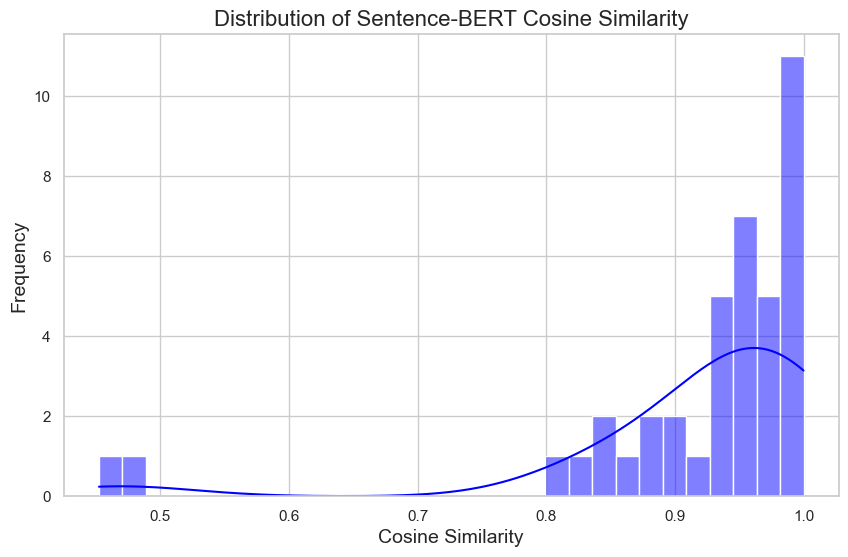

In [2]:
# Visualize BERT Cosine Similarity distribution
plt.figure(figsize=(10, 6))
sns.histplot(results_df["Sentence-BERT Cosine Similarity"], bins=30, kde=True, color="blue")
plt.title("Distribution of Sentence-BERT Cosine Similarity", fontsize=16)
plt.xlabel("Cosine Similarity", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.show()

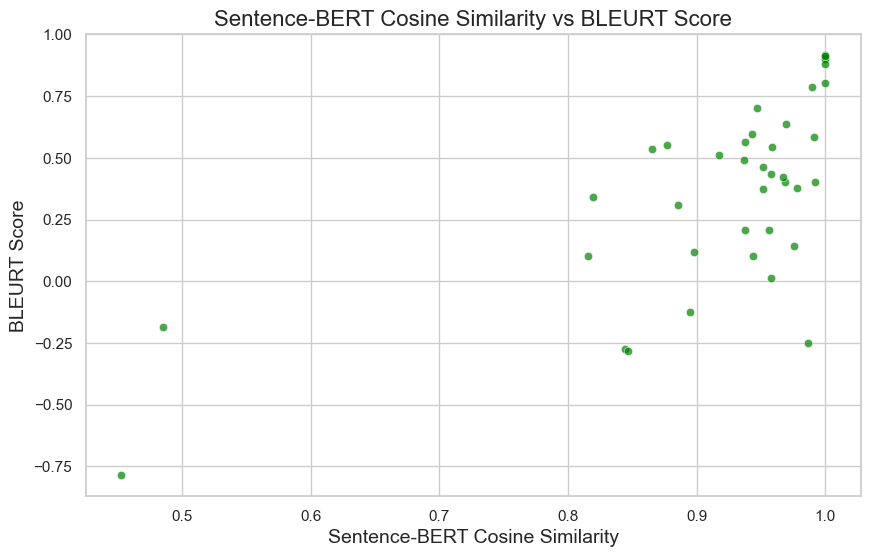

In [3]:
# Scatterplot for Sentence-BERT Cosine Similarity vs BLEURT Score
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=results_df["Sentence-BERT Cosine Similarity"],
    y=results_df["BLEURT Score"],
    alpha=0.7,
    color="green"
)
plt.title("Sentence-BERT Cosine Similarity vs BLEURT Score", fontsize=16)
plt.xlabel("Sentence-BERT Cosine Similarity", fontsize=14)
plt.ylabel("BLEURT Score", fontsize=14)
plt.show()

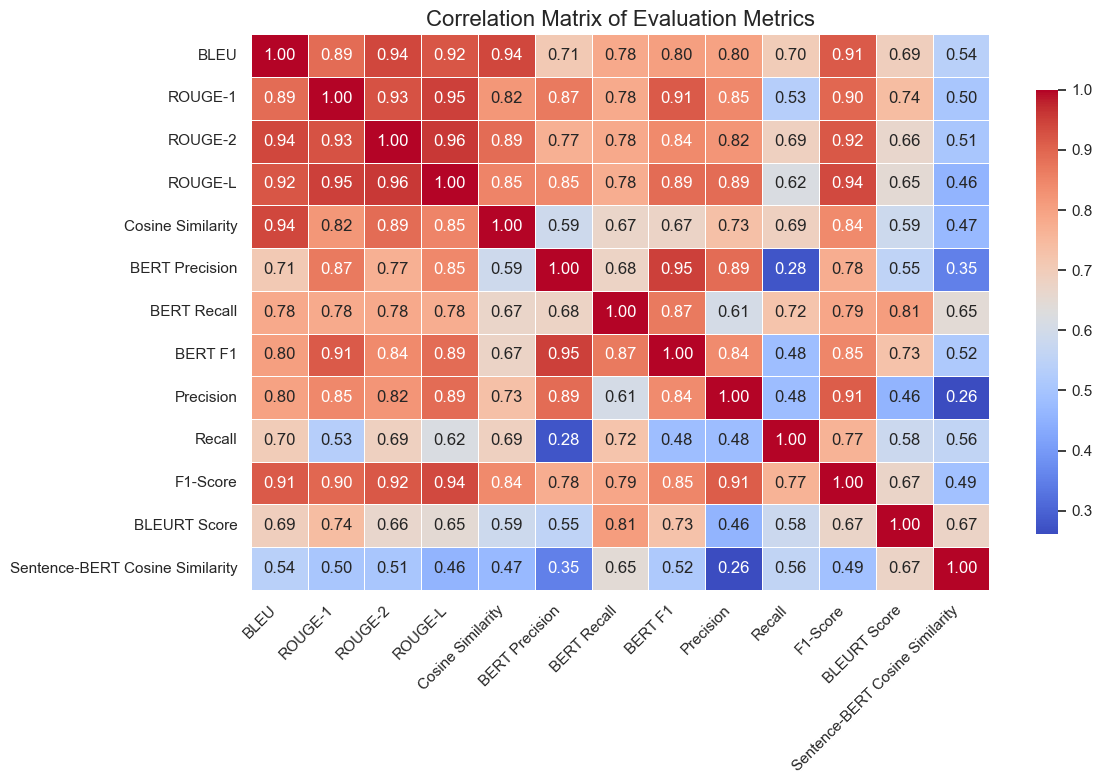

In [8]:
# Heatmap of correlations among metrics
correlation_matrix = results_df.select_dtypes(include=['float64', 'int64']).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Evaluation Metrics", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

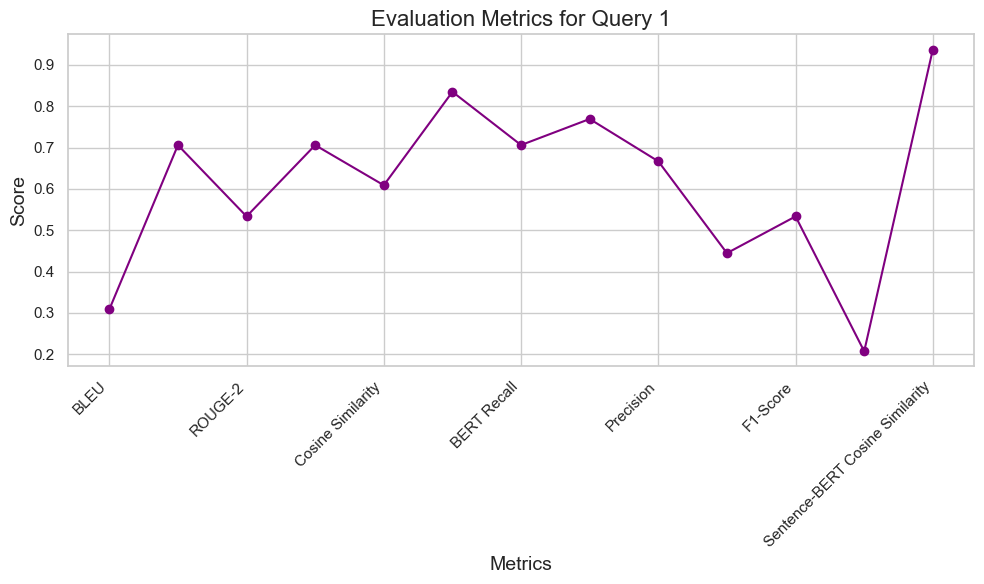

In [7]:
# Line plot for a sample query showing metric trends
sample_query_index = 0  # Change this index to visualize another query
sample_data = results_df.iloc[sample_query_index]
sample_metrics = sample_data.drop(["Query", "Expected", "Generated"], errors="ignore")
plt.figure(figsize=(10, 6))
sample_metrics.plot(kind="line", marker="o", color="purple")
plt.title(f"Evaluation Metrics for Query {sample_query_index+1}", fontsize=16)
plt.xlabel("Metrics", fontsize=14)
plt.ylabel("Score", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()